## Description
This notebook implements a linear classifier on top of a pre-trained DINOv2 model using pytorch.
The model is trained using the cvn dataset and was saved in a pth file. We load the model and get the intermediate layers to extract features from the images.
The data loader was adapted to load images and their corresponding labels from the cvn dataset.

The dataset used here are located in /nfs/data/1/rrazakami/work/dune-cvn/dataset_info: few sampled images and simple folder structure. Once the classification is working, we can move to the full dataset at /nfs/data/1/rrazakami/work/data_cvn

In [59]:
import numpy as np
import os
from pathlib import Path
import time
import copy
import matplotlib.pyplot as plt
from PIL import Image
import shutil
from tqdm import tqdm

#### Data loader: copy from cvn.py

In [60]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.io import read_image
from torchvision.transforms import v2
from torchvision.models.feature_extraction import create_feature_extractor
from dinov2.models.vision_transformer import vit_small, vit_base, vit_large

In [61]:
print(f'torch version: {torch.__version__}')
print(f'torchvision version: {torchvision.__version__}')

torch version: 2.3.1+cu121
torchvision version: 0.18.1+cu121


In [62]:
def fix_random_seeds(seed=53):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
fix_random_seeds()

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')
print(f'Device count : {torch.cuda.device_count()}')

Using device: cuda
Device count : 2


### Preparing the file structure

In [64]:
DATA_SOURCE = '/nfs/data/1/rrazakami/work/dune-cvn/dataset_info'
# DATA_ROOT = 'data_cvn'
# DATA_ROOT = DATA_SOURCE
DATA_ROOT ='/nfs/data/1/rrazakami/work/data_cvn/data/dune/2023_trainings/latest/dunevd'
os.makedirs(DATA_ROOT, exist_ok=True)
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [65]:
def create_dir_structure():
    def get_unique_filename(flavor='nutau'):
        # return unique list of prefixes in the flavor directory
        flavor_path = os.path.join(DATA_SOURCE, flavor)
        list_files = os.listdir(flavor_path)
        prefixes = [f.split('.')[0] for f in list_files if f.startswith('event')]
        unique_prefixes = list(set(prefixes))
        return unique_prefixes
    ## The particular dataset is balanced, so each flavor has the name number of events. This could be different for other datasets.
    N = len(get_unique_filename('nutau'))
    # N = 20
    print(f'Total number of events per flavor: {N}')

    # separate into train, val, test : 70%, 15%, 15%
    train_split = int(0.7 * N)
    val_split = int(0.15 * N)
    test_split = N - train_split - val_split
    # Each event is stored in a gz file with its corresponding .info file. We need to copy both files.
    ## Create train, val, and test directories
    train_path = os.path.join(DATA_ROOT, 'train')
    val_path = os.path.join(DATA_ROOT, 'val')
    test_path = os.path.join(DATA_ROOT, 'test')
    os.makedirs(train_path, exist_ok=True)
    os.makedirs(val_path, exist_ok=True)
    os.makedirs(test_path, exist_ok=True)
    # For each flavor, create subdirectories
    # flavors = os.listdir(DATA_SOURCE)
    flavors = ['nue', 'numu', 'nc']
    for flavor in flavors:
        os.makedirs(os.path.join(train_path, flavor), exist_ok=True)
        os.makedirs(os.path.join(val_path, flavor), exist_ok=True)
        os.makedirs(os.path.join(test_path, flavor), exist_ok=True)
    # Now, copy files into respective directories
    for flavor in flavors:
        list_files = get_unique_filename(flavor=flavor)
        flavor_path = os.path.join(DATA_SOURCE, flavor)
        for i, file in enumerate(list_files):
            src_file_gz = os.path.join(flavor_path, file + '.gz')
            src_file_info = os.path.join(flavor_path, file + '.info')
            if i < train_split:
                dest_dir = os.path.join(train_path, flavor)
                # dest_dir = os.path.join(train_path)
            elif i < train_split + val_split:
                dest_dir = os.path.join(val_path, flavor)
                # dest_dir = os.path.join(val_path)
            else:
                dest_dir = os.path.join(test_path, flavor)
                # dest_dir = os.path.join(test_path)
            shutil.copy(src_file_gz, dest_dir)
            shutil.copy(src_file_info, dest_dir)

In [66]:
# create_dir_structure()

### Creating models for feature extraction

In [67]:
## class for DINOv2
class ModelWithIntermediateLayers(nn.Module):
    def __init__(self, feature_model, n_last_blocks):
        super().__init__()
        self.feature_model = feature_model
        self.feature_model.eval()
        self.n_last_blocks = n_last_blocks

    def forward(self, images):
        # with torch.inference_mode():
        features = self.feature_model.get_intermediate_layers(images, self.n_last_blocks, return_class_token=True)
        return features

### Configuring the model

In [68]:
BACKBONE = 'dinov2'
model_configurator = {
    'dinov2': {
        'backbone_name': 'dinov2',
        # 'arch' : 'large', # Rado's training
        'arch': 'base', # Nitish's training
        'use_nblocks' : 1,
        'use_avgpool': True,
    }
}
# IMG_SIZE = 500 #168
# IMG_SIZE = 16*30
IMG_SIZE = 224
BATCH_SIZE = 32 #8
NUM_WORKERS = 0
# PATCH_SIZE = 25 #56
PATCH_SIZE = 16

In [69]:
import yaml
with open('/nfs/data/1/nitish/dino_output/cvn_properrun_1gpu/config.yaml','r') as f:
    config = yaml.safe_load(f)

In [70]:
16*30

480

In [71]:
config['student']['arch']

'vit_base'

In [72]:
model_config = model_configurator[BACKBONE]
if BACKBONE=='dinov2':
    backbone_archs = {
        'vit_small': vit_small,
        'vit_base': vit_base,
        'vit_large': vit_large
    }
    # backbone_arch = backbone_archs[model_config['arch']]
    backbone_arch = backbone_archs[config['student']['arch']]
    backbone_name = f'dinov2_{backbone_arch}'
    print(f'Using backbone: {backbone_name}')
    # load model
    # backbone_model = vit_large(patch_size=PATCH_SIZE, img_size=IMG_SIZE) ## <<== This is wrong. We need to use the same arch as used in training
    backbone_model = backbone_arch(patch_size=PATCH_SIZE, img_size=IMG_SIZE)
    backbone_model.to(device)
    for p in backbone_model.parameters():
        p.requires_grad = False
    backbone_model.eval()
    # pth_model = torch.load('../out_cvn_memlite_batchpergpu_16/model_final.rank_0.pth')
    pth_model = torch.load('/nfs/data/1/nitish/dino_output/cvn_properrun_1gpu/model_final.rank_0.pth')
    backbone_model.load_state_dict(pth_model, strict=False)
    feature_model = ModelWithIntermediateLayers(backbone_model, n_last_blocks=model_config['use_nblocks'])
    embed_dim = backbone_model.embed_dim * (model_config['use_nblocks'] + int(model_config['use_avgpool']))
    print(f'Feature dimension: {embed_dim}')
feature_model = feature_model.to(device)

Using backbone: dinov2_<function vit_base at 0x7f2a90df8900>
Feature dimension: 1536


### Creating a linear classifier

In [73]:
def create_linear_input(x_tokens_list, use_nblocks, use_avgpool):
    intermediate_output = x_tokens_list[-use_nblocks:]  # list of tensors from the last n blocks
    output = torch.cat([class_token for _, class_token in intermediate_output], dim=-1)  # concatenate class tokens
    # print(f'patch tokens shape: {intermediate_output[-1][0].shape}')
    # print(f'output shape before avgpool: {output.shape}')
    if use_avgpool:
        output = torch.cat(
            (
                output,
                torch.mean(intermediate_output[-1][0], dim=1), # patch tokens
            ),
            dim=-1,
        )
        output = output.reshape(output.shape[0], -1)
        # print(f'output shape after avgpool: {output.shape}')
    return output.float()

In [74]:
class LinearClassifier(nn.Module):
    def __init__(self, out_dim, config, num_classes=4):
        super().__init__()
        self.out_dim = out_dim
        if config['backbone_name'] == 'dinov2':
            self.use_dinov2= True
            self.use_nblocks = config['use_nblocks']
            self.use_avgpool = config['use_avgpool']
        self.num_classes = num_classes
        self.linear = nn.Linear(self.out_dim, self.num_classes)
        self.linear.weight.data.normal_(mean=0.0, std=0.01)
        self.linear.bias.data.zero_()
    
    def forward(self, input):
        if self.use_dinov2:
            output = create_linear_input(input, self.use_nblocks, self.use_avgpool)
            return self.linear(output)

linear_classifier = LinearClassifier(embed_dim, model_config, num_classes=4) # nu and nubar in the same class. No nutau
linear_classifier = linear_classifier.to(device)

In [75]:
linear_classifier

LinearClassifier(
  (linear): Linear(in_features=1536, out_features=4, bias=True)
)

### Defining datasets and dataloaders

In [76]:
from dinov2.data import DataAugmentationDINO, SamplerType, make_data_loader, make_dataset
from dinov2.data import MaskingGenerator, collate_data_and_cast
from functools import partial
import yaml

with open('../dinov2/configs/ssl_default_config.yaml') as f:
    cfg = yaml.safe_load(f)
# cfg = yaml.safe_load(open('../dinov2/configs/ssl_default_config.yaml'))
cfg['train']['batch_size_per_gpu'] = BATCH_SIZE
cfg['crops']['global_crops_size'] = IMG_SIZE
cfg['student']['patch_size'] = PATCH_SIZE

img_size = cfg["crops"]["global_crops_size"]
patch_size = cfg["student"]["patch_size"]

In [77]:
n_tokens = (img_size // patch_size) ** 2  # +1 for CLS token
mask_generator = MaskingGenerator(
        input_size=(img_size // patch_size, img_size // patch_size),
        max_num_patches=0.5 * img_size // patch_size * img_size // patch_size,
    )

data_transform = DataAugmentationDINO(
    global_crops_scale=cfg["crops"]["global_crops_scale"],
    global_crops_size=cfg["crops"]["global_crops_size"],
    local_crops_size=cfg["crops"]["local_crops_size"],
)

# collate_fn = partial(
#     collate_data_and_cast,
#     mask_ratio_tupe=cfg["ibot"]["mask_ratio_min_max"],
#     mask_probability=cfg["ibot"]["mask_sample_probability"],
#     n_tokens=n_tokens,
#     mask_generator=mask_generator,
#     dtype=torch.half,
# )

# def custom_collate_fn(batch):
#     images = torch.stack([item[0] for item in batch])
#     labels = torch.tensor([item[1] for item in batch])
#     extra = [item[2] for item in batch]
#     return images, labels, extra
    
LARGE_DATASET = True
if not LARGE_DATASET:
    kwargs = {}
    datasets = {x: make_dataset(dataset_str=f"CVN:root={DATA_ROOT}/{x}:extra=plane=Z,mono=mono3", transform=data_transform,
                                target_transform=None) for x in ['train', 'val']}
    dataloaders = {x: make_data_loader(
        dataset=datasets[x],
        batch_size=cfg["train"]["batch_size_per_gpu"],
        num_workers=cfg["train"]["num_workers"],
        shuffle=True,
        sampler_type=SamplerType.EPOCH
    ) for x in ['train', 'val']}

    dataset_sizes = {x: len(datasets[x]) for x in ['train', 'val']}
    class_names = datasets['train'].classes
    # class_names = datasets['train'].pdgs

    print(f"Data loaded with {dataset_sizes['train']} training samples and {dataset_sizes['val']} validation samples.")

    datasets['test'] = make_dataset(dataset_str=f"CVN:root={DATA_ROOT}/test:extra=plane=Z,mono=mono3", transform=data_transform,
                            target_transform=None)
    dataloaders['test'] = make_data_loader(
        dataset=datasets['test'],
        batch_size=cfg["train"]["batch_size_per_gpu"],
        num_workers=cfg["train"]["num_workers"],
        shuffle=True,
    )
    dataset_sizes['test'] = len(datasets['test'])
    print(f'Data loaded with {dataset_sizes["test"]} test samples.')

In [78]:
from torch.utils.data import random_split, SubsetRandomSampler, Subset, DataLoader
datasets_train, datasets_val, datasets_test = None, None, None

data_transform = DataAugmentationDINO(
    global_crops_scale=cfg["crops"]["global_crops_scale"],
    global_crops_size=cfg["crops"]["global_crops_size"],
    local_crops_size=cfg["crops"]["local_crops_size"],
)

if LARGE_DATASET:
    datasets_full = make_dataset(dataset_str=f"CVN:root={DATA_ROOT}:extra=plane=Z,mono=mono3", transform=data_transform,
                                target_transform=None)
    # ## split dataset into train, val, test withoout modifying the original dataset.
    # Nfull = len(datasets_full)
    # N = 10000  # for testing purpose
    # print(f'Total number of samples in the dataset: {N}')
    # Ntrain = int(0.7 * N)
    # Nval = int(0.15 * N)
    # Ntest = N - Ntrain - Nval
    # # datasets_train, datasets_val, datasets_test = random_split(datasets_full, [Ntrain, Nval, Ntest])
    # indices = np.random.permutation(Nfull)
    # train_indices = np.array(indices[:Ntrain])
    # val_indices = np.array(indices[Ntrain:Ntrain+Nval])
    # test_indices = np.array(indices[Ntrain+Nval:])
    # print(f'train_indices: {train_indices}')
    # print(f'val_indices: {val_indices}')
    # print(f'test_indices: {test_indices}')
    # datasets_train, datasets_val, datasets_test = Subset(datasets_full, train_indices), Subset(datasets_full, val_indices), Subset(datasets_full, test_indices)
    # print(f'Number of training samples: {len(datasets_train)}')
    # print(f'type(datasets_train): {type(datasets_train)}')
    # print(f'datasets_train[0]: {datasets_train[0]}')
    # dataloaders = {
    #     'train': make_data_loader(
    #         dataset=datasets_train,
    #         batch_size=cfg["train"]["batch_size_per_gpu"],
    #         sampler_type=SamplerType.EPOCH,
    #         num_workers=0,
    #         shuffle=True
    #     ),
    #     'val': make_data_loader(
    #         dataset=datasets_val,
    #         batch_size=cfg["train"]["batch_size_per_gpu"],
    #         sampler_type=SamplerType.EPOCH,
    #         num_workers=0,
    #         shuffle=True
    #     ),
    #     'test': make_data_loader(
    #         dataset=datasets_test,
    #         batch_size=cfg["train"]["batch_size_per_gpu"],
    #         num_workers=0,
    #         sampler_type=SamplerType.EPOCH,
    #     )
    # }
    
    from sklearn.model_selection import train_test_split
    total_size = len(datasets_full)
    subset_size = 20000
    print(f'Total number of samples in the dataset: {total_size}')
    print(f'Selecting a subset of size: {subset_size}')

    # Randomly select 50k indices
    np.random.seed(42)
    selected_indices = np.random.choice(total_size, size=subset_size, replace=False)

    # Get labels for the selected samples (needed for stratification)
    selected_labels = []
    for idx in selected_indices:
        _, label = datasets_full[idx]
        selected_labels.append(label if isinstance(label, int) else label.item())
    selected_labels = np.array(selected_labels)

    # First split: train (70%) vs temp (30%)
    train_indices, temp_indices, train_labels, temp_labels = train_test_split(
        selected_indices,
        selected_labels,
        test_size=0.3,
        stratify=selected_labels,
        random_state=42
    )

    # Second split: val (15%) and test (15%) from temp
    val_indices, test_indices = train_test_split(
        temp_indices,
        test_size=0.5,
        stratify=temp_labels,
        random_state=42
    )

    # Create subsets
    datasets_train = Subset(datasets_full, train_indices)
    datasets_val = Subset(datasets_full, val_indices)
    datasets_test = Subset(datasets_full, test_indices)
    print(f'Number of training samples: {len(datasets_train)}')
    print(f'Number of validation samples: {len(datasets_val)}')
    print(f'Number of test samples: {len(datasets_test)}')

Total number of samples in the dataset: 4155839
Selecting a subset of size: 20000
Number of training samples: 14000
Number of validation samples: 3000
Number of test samples: 3000


In [79]:
dataloaders = {
        'train': make_data_loader(
            dataset=datasets_train,
            batch_size=cfg["train"]["batch_size_per_gpu"],
            sampler_type=SamplerType.EPOCH,
            num_workers=0,
            shuffle=True
        ),
        'val': make_data_loader(
            dataset=datasets_val,
            batch_size=cfg["train"]["batch_size_per_gpu"],
            sampler_type=SamplerType.EPOCH,
            num_workers=0,
            shuffle=True
        ),
        'test': make_data_loader(
            dataset=datasets_test,
            batch_size=cfg["train"]["batch_size_per_gpu"],
            num_workers=0,
            sampler_type=SamplerType.EPOCH,
        )
    }

In [80]:
def check_dataset(dataset, num_samples=100):
    import random
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    for i in indices:
        try:
            sample = dataset[i]
            if not isinstance(sample, tuple) or len(sample) != 2:
                print(f"Index {i}: unexpected structure: {type(sample)}")
            elif isinstance(sample[0], dict) or isinstance(sample[1], dict):
                print(f"Index {i}: contains dict! sample[0]={type(sample[0])}, sample[1]={type(sample[1])}")
                print(f"sample[0] keys: {sample[0].keys() if isinstance(sample[0], dict) else 'N/A'}")
                print(sample[1])
                break
        except Exception as e:
            print(f"Index {i}: error - {e}")

In [81]:
# check_dataset(datasets_full, num_samples=100000)

In [82]:
class_names = datasets_full.classes

In [83]:
class_names

['nu', 'nue', 'nutau', 'nc']

In [84]:
dataloaders['train']

In [85]:
for k in dataloaders['train']:
    print(f'images type: {type(k)}')
    print(k)
    break

images type: <class 'list'>
[tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.

In [86]:
batch = next(iter(dataloaders['train']))

### Visualizing some examples

In [87]:
def show_batch(imgs, titles=None, rows=2, cols=4, figname=None):
    if titles is None:
        titles = ['image ' + str(i) for i in range(imgs.size(0))]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    if (cols!=1) & (rows!=1):
        fig = plt.figure(figsize=(cols * 3, rows * 3))
    else:
        fig = plt.figure(figsize=(10,10))
    # for i in range(imgs.size(0)):
    # print(f'imgs.size() : {imgs.size()}')
    # print(f'imgs.size(0) : {imgs.size(0)}')
        # img = imgs[i].cpu().numpy().transpose((1, 2, 0))
    img = imgs[0].cpu().numpy().transpose((1,2,0))
    print(f'image shape : {img.shape}')
    # img = img * std + mean  # unnormalize
    # img = np.clip(img, 0, 1)
    i = 0
    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(img[:, :, 0], cmap='viridis') ## just cmap='gray' doesn't change this to gray
    ax.set_title(titles[i])
    ax.axis('off')
    fig.tight_layout()
    if figname is not None:
        plt.savefig(figname)
        plt.close()

image shape : (224, 224, 3)


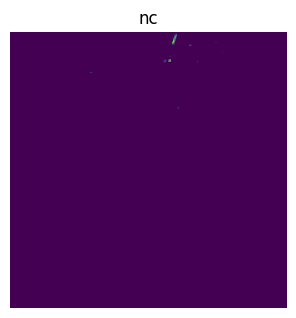

In [88]:
inputs, classes = None, None
for _ in range(10):
    try:
        inputs, classes = next(iter(dataloaders['train']))
        break
    except:
        pass
# inputs, classes, _ = next(iter(test))

nu_PDGs = {
    12: r'$\nu_e$',
    -12: r'$\bar{\nu}_e$',
    14: r'$\nu_{\mu}$',
    -14: r'$\bar{\nu}_{\mu}$',
    16: r'$\nu_{\tau}$',
    -16: r'$\bar{\nu}_{\tau}$',
}
show_batch(inputs, titles=[class_names[cls] for cls in classes], rows=4, cols=8)
# show_batch(inputs, titles=[f'{nu_PDGs[cls.item()]}, PDG = {cls.item()}' for cls in classes], rows=4, cols=4)

In [89]:
# inputs, classes, _ = next(iter(dataloaders['val']))
# show_batch(inputs, titles=[class_names[cls] for cls in classes], rows=4, cols=8)
# show_batch(inputs, titles=[f'{nu_PDGs[cls.item()]}, PDG = {cls.item()}' for cls in classes], rows=4, cols=4)

In [90]:
# inputs, classes, _ = next(iter(dataloaders['test']))
# show_batch(inputs, titles=[class_names[cls] for cls in classes], rows=4, cols=8)
# show_batch(inputs, titles=[f'{nu_PDGs[cls.item()]}, PDG = {cls.item()}' for cls in classes], rows=4, cols=4)

### Train and validation loops

In [91]:
def train_loop(dataloader, feature_model, linear_classifier, loss_fn, optimizer):
    linear_classifier.train()
    size = len(dataloader.dataset)
    print(f'Dataset size: {size}')
    total_samples = 0
    # num_batches = len(dataloader[0]['global_crops'])
    num_batches = BATCH_SIZE
    running_loss = 0.0
    running_corrects = 0
    for batch, (X,y) in enumerate(dataloader):
        print(f'Batch {batch+1}/{num_batches}', end='\r')
        X = X.to(device)
        y = y.to(device)
        features = feature_model(X)
        # f = features[0][0].cpu().numpy()
        # features = feature_model.forward(X)
        pred = linear_classifier(features)
        # print(f'pred shape : {pred.shape}, values : {pred}')
        # print(f'y shape : {y.shape}, values : {y}')
        loss = loss_fn(pred, y)
        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        # Statistics
        running_loss += loss.item()
        running_corrects += (pred.argmax(1) == y).type(torch.float).sum().item()
        total_samples += y.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    print(f'len(running_corrects) : {running_corrects}, total_samples : {total_samples}')
    return epoch_acc, epoch_loss

In [92]:
# @torch.inference_mode()
def val_loop(dataloader, feature_model, linear_classifier, loss_fn):
    feature_model.eval()
    linear_classifier.eval()
    size = len(dataloader.dataset)
    total_samples = 0
    num_batches = BATCH_SIZE
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            features = feature_model(X)
            # features = feature_model.forward_backward(X)
            pred = linear_classifier(features)
            val_loss += loss_fn(pred, y).item()
            val_acc += (pred.argmax(1) == y).type(torch.float).sum().item()
            total_samples += y.size(0)
    val_loss /= total_samples
    val_acc /= total_samples
    return val_acc, val_loss

### Loss function, optimizer, scheduler

In [93]:
EPOCHS = 15
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    linear_classifier.parameters(),
    # lr=cfg['optim']['base_lr'],
    lr=0.01,
    momentum=0.9,
    weight_decay=0.0
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, EPOCHS, eta_min=0)

In [94]:
best_acc = 0.0
best_acc_loss = np.inf
train_data = []
for t in range(EPOCHS): # epochs
    print(f'Epoch {t+1}\n-------------------------------')

    train_acc, train_loss = train_loop(dataloaders['train'], feature_model, linear_classifier, loss_fn, optimizer)
    train_data.append({
        'phase': 'train',
        'epoch': t,
        'lr': optimizer.param_groups[0]['lr'],
        'accuracy': train_acc,
        'loss': train_loss
    })
    scheduler.step()
    print(f'Train: \n  Train_acc = {train_acc:.4f}, Train_loss = {train_loss:.4f}')
    val_acc, val_loss = val_loop(dataloaders['val'], feature_model, linear_classifier, loss_fn)
    print(f'Validation:\n    val_acc = {val_acc}, val_loss = {val_loss}')
    train_data.append({
        'phase': 'val',
        'epoch': t,
        'lr': optimizer.param_groups[0]['lr'],
        'accuracy': val_acc,
        'loss': val_loss
    })
    if (val_acc == best_acc and val_loss < best_acc_loss) or (val_acc > best_acc):
        best_acc, best_acc_loss = val_acc, val_loss
        save_dict = {
            'epoch': t+1,
            'state_dict': linear_classifier.state_dict(),
            'optimizer': optimizer.state_dict(),
            'best_acc': best_acc,
            'best_acc_loss': best_acc_loss
        }
        torch.save(save_dict, os.path.join(OUTPUT_DIR, 'linear_classifier_best.pth'))
    print('\n')
print('Training completed.')

Epoch 1
-------------------------------
Dataset size: 14000


len(running_corrects) : 4588.0, total_samples : 13984
Train: 
  Train_acc = 0.3281, Train_loss = 0.3010
Validation:
    val_acc = 0.2698252688172043, val_loss = 0.3522718359706222


Epoch 2
-------------------------------
Dataset size: 14000
len(running_corrects) : 4889.0, total_samples : 13984
Train: 
  Train_acc = 0.3496, Train_loss = 0.3033
Validation:
    val_acc = 0.4156586021505376, val_loss = 0.14010965984354737


Epoch 3
-------------------------------
Dataset size: 14000
len(running_corrects) : 4918.0, total_samples : 13984
Train: 
  Train_acc = 0.3517, Train_loss = 0.2539
Validation:
    val_acc = 0.4264112903225806, val_loss = 0.1760957446950738


Epoch 4
-------------------------------
Dataset size: 14000
len(running_corrects) : 4972.0, total_samples : 13984
Train: 
  Train_acc = 0.3555, Train_loss = 0.2203
Validation:
    val_acc = 0.40625, val_loss = 0.31394915346817304


Epoch 5
-------------------------------
Dataset size: 14000
len(running_corrects) : 5177.0, total_sam

### Model information

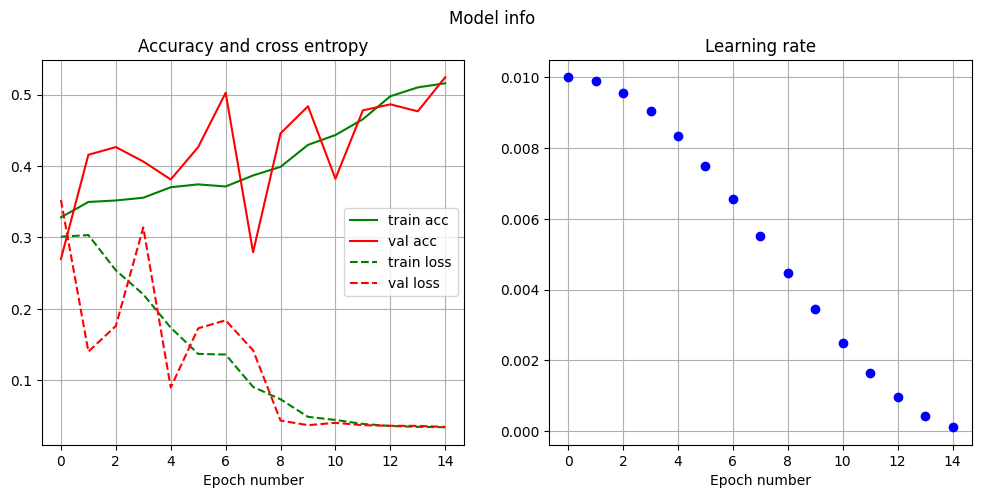

In [95]:
import pandas as pd
train_df = pd.DataFrame(train_data)
train_df.to_csv(os.path.join(OUTPUT_DIR, 'training_log.csv'), index=False)
train_phase = train_df[train_df['phase']=='train']
val_phase = train_df[train_df['phase']=='val']
y_axis = 'accuracy'
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,5))
line_acc_train, = ax1.plot(train_phase['epoch'], train_phase['accuracy'], 'g-', label='train acc')
line_acc_val, = ax1.plot(val_phase['epoch'], val_phase['accuracy'], 'r-', label='val acc')
line_loss_train, = ax1.plot(train_phase['epoch'], train_phase['loss'], 'g--', label='train loss')
line_loss_val, = ax1.plot(val_phase['epoch'], val_phase['loss'], 'r--', label='val loss')
ax1.set_xlabel('Epoch number')
ax1.legend(loc='center right')
ax1.set_title('Accuracy and cross entropy')
ax1.grid(visible=True)
line_lr = ax2.plot(train_phase['epoch'], train_phase['lr'], 'ob', label='learning rate')
ax2.set_xlabel('Epoch number')
ax2.set_title('Learning rate')
ax2.grid(visible=True)
fig.suptitle('Model info')
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'))
plt.show()

### Visualization of predictions

In [96]:
print(class_names)

['nu', 'nue', 'nutau', 'nc']


In [97]:
def visualize_model(feature_model, linear_classifier, images,original_img=None, rows=2, cols=4, true_classes=None, batch_no=None):
    was_training = linear_classifier.training
    linear_classifier.eval()
    with torch.no_grad():
        imgs = images.to(device)
        # print(f'Input image shape: {imgs.shape}')
        features = feature_model(imgs)
        outputs = linear_classifier(features)
        outputs = nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        print(f'Predicted classes: {preds}')
        print(f'True classes: {true_classes}')
        print(f'Outputs: {outputs}')
        # titles = [f'{class_names[preds[i]]}: {outputs[i, preds[i]].squeeze().item():.3f}; true : {class_names[true_classes[i]]}' for i in range(imgs.size(0))]
        titles = [f'{class_names[preds[0]]}: {outputs[0, preds[0]].squeeze().item():.3f}; true : {class_names[true_classes]}']
    print(f'imgs size : {imgs.size()}')
    # figname = f'output/predictions/predictions_batch_{batch_no}.png' if batch_no is not None else 'output/predictions/predictions_batch.png'
    figname = f'output/predictions/predictions{class_names[preds[0]]}_true{class_names[true_classes]}_batch{batch_no}.png' if batch_no is not None else f'output/predictions/predictions{class_names[preds[0]]}_true{class_names[true_classes]}_batch.png'
    if original_img is not None:
        imgs = original_img
    show_batch(imgs, titles=titles, rows=rows, cols=cols, figname=figname)
    
    linear_classifier.train(mode=was_training)
    return figname, class_names[preds[0]], class_names[true_classes]

In [98]:
# i = 0
# for batch_no, (imgs, true_classes) in enumerate(dataloaders['test']):
#     # if i==2:
#         # break
#     # imgs, true_classes = next(iter(dataloaders['test']))
#     visualize_model(feature_model=feature_model, linear_classifier=linear_classifier, images=imgs, true_classes=true_classes, rows=4, cols=8, batch_no=batch_no)
#     i += 1

In [99]:
predictions_dict = {
    'figname': [],
    'predicted_class': [],
    'true_class': []
}
# for no, (img, label) in enumerate(datasets['test']):
for no, (img, label) in enumerate(datasets_test):
    img = img[np.newaxis, ...]
    figname, predicted_class, true_class = visualize_model(feature_model=feature_model, linear_classifier=linear_classifier, images=img, original_img=None, true_classes=label, rows=1, cols=1, batch_no=no)
    predictions_dict['figname'].append(figname)
    predictions_dict['predicted_class'].append(predicted_class)
    predictions_dict['true_class'].append(true_class)

Predicted classes: tensor([0], device='cuda:0')
True classes: 3
Outputs: tensor([[0.3919, 0.2760, 0.0635, 0.2685]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([3], device='cuda:0')
True classes: 3
Outputs: tensor([[0.2273, 0.1122, 0.0114, 0.6491]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([3], device='cuda:0')
True classes: 1
Outputs: tensor([[0.2574, 0.2493, 0.0308, 0.4624]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([2], device='cuda:0')
True classes: 1
Outputs: tensor([[0.1470, 0.1970, 0.6513, 0.0047]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([0], device='cuda:0')
True classes: 0
Outputs: tensor([[0.3572, 0.2962, 0.0482, 0.2985]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224

Outputs: tensor([[0.1025, 0.6548, 0.0348, 0.2079]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([3], device='cuda:0')
True classes: 0
Outputs: tensor([[0.3016, 0.1578, 0.0213, 0.5193]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([1], device='cuda:0')
True classes: 1
Outputs: tensor([[0.1532, 0.6392, 0.1258, 0.0818]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([0], device='cuda:0')
True classes: 1
Outputs: tensor([[0.3827, 0.2159, 0.1020, 0.2994]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([0], device='cuda:0')
True classes: 3
Outputs: tensor([[0.4759, 0.2355, 0.2039, 0.0847]], device='cuda:0')
imgs size : torch.Size([1, 3, 224, 224])
image shape : (224, 224, 3)
Predicted classes: tensor([1], device='cuda:0')
True c

In [100]:
predictions_df = pd.DataFrame(predictions_dict)
accuracy = (predictions_df['predicted_class'] == predictions_df['true_class']).sum() / len(predictions_df)
print(f'Test set accuracy: {accuracy:.4f}')

Test set accuracy: 0.5107


In [101]:
predictions_df.to_csv(os.path.join(OUTPUT_DIR, 'test_set_predictions.csv'), index=False)

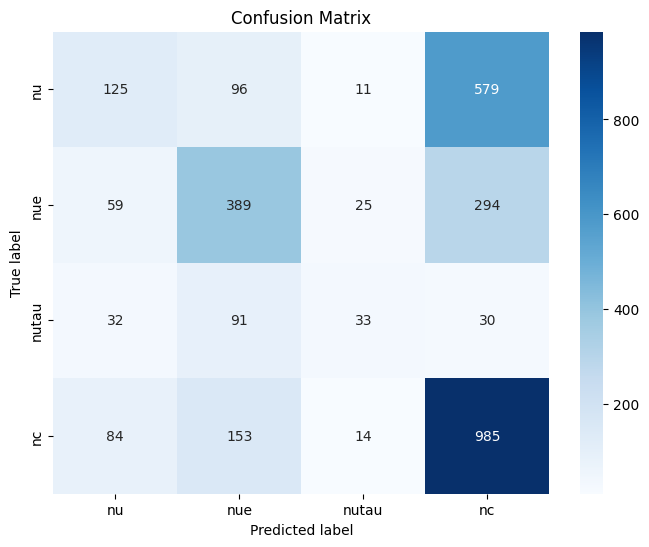

In [102]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(predictions_df['true_class'], predictions_df['predicted_class'], labels=class_names)

import seaborn as sns
f, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix')
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'))
plt.show()